In [1]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 15: K-Nearest Neighbors Classifier
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Tasks: Power State | Eclipse State | Power Level
# Algorithm: Instance-based learning — no explicit training
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print()
print("KNN — Instance-Based Learning")
print("Training : No explicit optimization — stores all training points")
print("Tuning   : n_neighbors (k), metric, weights")
print("Why RandomizedSearchCV:")
print("  k ranges from 1 to 100+ — too many values for exhaustive grid")
print("  Random sampling over this range finds optimal k efficiently")
print("  Combined with categorical params (metric, weights), random")
print("  search covers the joint space better per unit compute time")
print()
print("Classification Tasks:")
print("  Task 1 : Power State   — CHARGING / DISCHARGING / CRITICAL")
print("  Task 2 : Eclipse State — SUNLIGHT / ECLIPSE")
print("  Task 3 : Power Level   — HIGH / MEDIUM / LOW")

All libraries imported successfully

KNN — Instance-Based Learning
Training : No explicit optimization — stores all training points
Tuning   : n_neighbors (k), metric, weights
Why RandomizedSearchCV:
  k ranges from 1 to 100+ — too many values for exhaustive grid
  Random sampling over this range finds optimal k efficiently
  Combined with categorical params (metric, weights), random
  search covers the joint space better per unit compute time

Classification Tasks:
  Task 1 : Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2 : Eclipse State — SUNLIGHT / ECLIPSE
  Task 3 : Power Level   — HIGH / MEDIUM / LOW


In [2]:
# ============================================================
# SECTION 1: DATA LOADING + CLASS DEFINITION
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ============================================================
# TASK 1: POWER STATE
# CHARGING    : Charging=1 AND Vbat >= 3.90V
# DISCHARGING : Charging=0 AND Vbat >= 3.90V
# CRITICAL    : Vbat < 3.90V
# ============================================================
def define_power_state(row):
    if row['Vbat (V)'] < 3.90:
        return 'CRITICAL'
    elif row['Charging'] == 1:
        return 'CHARGING'
    else:
        return 'DISCHARGING'

df['Power_State']  = df.apply(define_power_state, axis=1)
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})
# Power_Level already exists in dataset

# ============================================================
# FEATURE SETS — Leakage-free per task
# ============================================================

# Task 1: Exclude Charging, Ibatt, P_batt, Vbat
FEATURES_POWER_STATE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)',
    'sin_orbit', 'cos_orbit'
]

# Task 2: Exclude Eclipse, P_solar_total, all currents
FEATURES_ECLIPSE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)',
    'sin_orbit', 'cos_orbit'
]

# Task 3: Exclude Vbat, P_solar_total, Charging, all currents
FEATURES_POWER_LEVEL = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)',
    'sin_orbit', 'cos_orbit'
]

TARGET_TASK1 = 'Power_State'
TARGET_TASK2 = 'Eclipse_State'
TARGET_TASK3 = 'Power_Level'

# TimeSeriesSplit — last fold for train/test
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# ============================================================
# SCALING — KNN is distance-based, scaling is MANDATORY
# Without scaling, features in mV dominate over features in °C
# ============================================================
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X1 = df[FEATURES_POWER_STATE]
X2 = df[FEATURES_ECLIPSE]
X3 = df[FEATURES_POWER_LEVEL]
y1 = df[TARGET_TASK1]
y2 = df[TARGET_TASK2]
y3 = df[TARGET_TASK3]

X1_train = scaler1.fit_transform(X1.iloc[train_idx])
X1_test  = scaler1.transform(X1.iloc[test_idx])
X2_train = scaler2.fit_transform(X2.iloc[train_idx])
X2_test  = scaler2.transform(X2.iloc[test_idx])
X3_train = scaler3.fit_transform(X3.iloc[train_idx])
X3_test  = scaler3.transform(X3.iloc[test_idx])

y1_train = y1.iloc[train_idx]; y1_test = y1.iloc[test_idx]
y2_train = y2.iloc[train_idx]; y2_test = y2.iloc[test_idx]
y3_train = y3.iloc[train_idx]; y3_test = y3.iloc[test_idx]

datasets = {
    'Power_State'  : (X1_train, X1_test, y1_train, y1_test,
                      FEATURES_POWER_STATE,  scaler1, X1, y1),
    'Eclipse_State': (X2_train, X2_test, y2_train, y2_test,
                      FEATURES_ECLIPSE,      scaler2, X2, y2),
    'Power_Level'  : (X3_train, X3_test, y3_train, y3_test,
                      FEATURES_POWER_LEVEL,  scaler3, X3, y3)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print(f"\nNOTE: StandardScaler applied — KNN uses Euclidean distance,")
print(f"      so all features must be on the same scale.")
print(f"\n{'='*50}")
print(f"CLASS DISTRIBUTIONS")
print(f"{'='*50}")
for task, target in [('Task 1', TARGET_TASK1),
                      ('Task 2', TARGET_TASK2),
                      ('Task 3', TARGET_TASK3)]:
    print(f"\n{task} — {target}:")
    for cls, cnt in df[target].value_counts().items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

Mounted at /content/drive
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876

NOTE: StandardScaler applied — KNN uses Euclidean distance,
      so all features must be on the same scale.

CLASS DISTRIBUTIONS

Task 1 — Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Task 2 — Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Task 3 — Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)


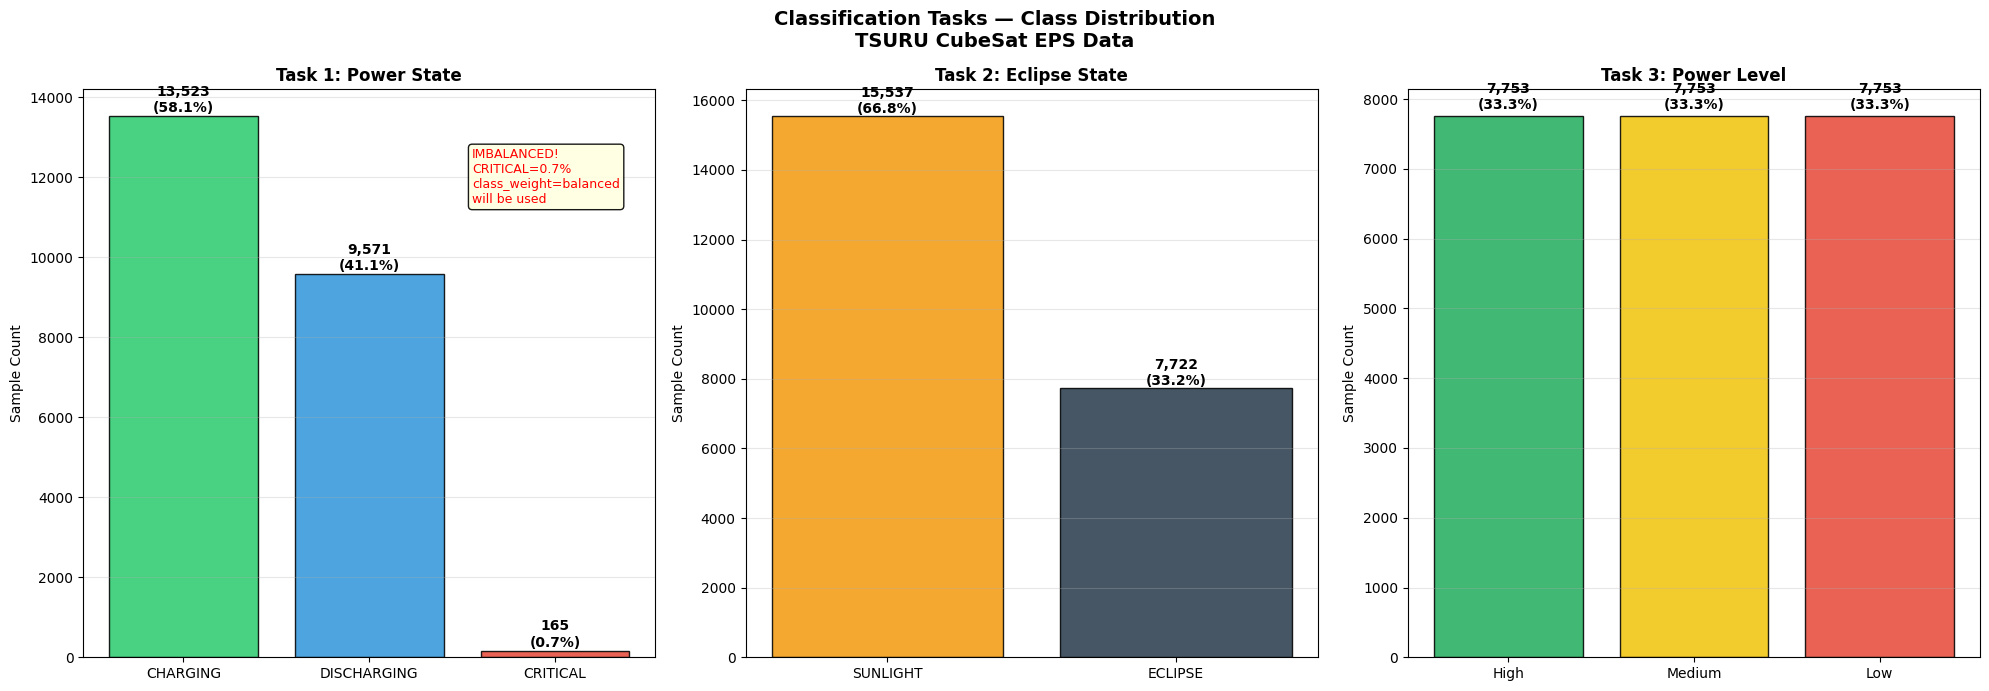

Class distribution plot saved.


In [3]:
# ============================================================
# SECTION 2: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data', fontsize=14, fontweight='bold')

# Task 1 — Power State
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1, color=['#2ecc71','#3498db','#e74c3c'], edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80, 'IMBALANCED!\nCRITICAL=0.7%\nclass_weight=balanced\nwill be used', transform=axes[0].transAxes, fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2 — Eclipse State
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2, color=['#f39c12','#2c3e50'], edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Task 3 — Power Level (High/Medium/Low — matches dataset exactly)
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3, color=['#27ae60','#f1c40f','#e74c3c'], edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

## Class Distribution Observations

- **Task 1 — Power State:** Severely imbalanced — CHARGING (58.1%) and
  DISCHARGING (41.1%) dominate while CRITICAL has only 165 samples (0.7%).
  KNN has no built-in class weighting mechanism, so CRITICAL will be
  difficult to detect — this is a known limitation evaluated below.

- **Task 2 — Eclipse State:** Moderately imbalanced — SUNLIGHT (66.8%)
  vs ECLIPSE (33.2%). Both classes are large enough for KNN to learn
  clear distance boundaries in feature space.

- **Task 3 — Power Level:** Perfectly balanced — HIGH, MEDIUM, LOW each
  have exactly 7,753 samples (33.3%). This is the most favorable class
  distribution for KNN.

In [4]:
# ============================================================
# SECTION 3: BASE MODEL — DEFAULT PARAMETERS
# KNN stores all training points — no weight optimization
# Prediction: majority vote among k=5 nearest neighbors
# Distance metric: Euclidean (minkowski p=2)
# Weights: uniform (all neighbors vote equally)
# NOTE: No class_weight parameter in KNN — imbalance handled
#       by evaluating per-class metrics separately
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — DEFAULT PARAMETERS")
print("k=5 | metric=minkowski(p=2) | weights=uniform")
print("=" * 65)
print()
print("KNN Algorithm:")
print("  1. Store all 19,383 training points in memory")
print("  2. For each test point, compute distance to ALL training points")
print("  3. Find 5 nearest neighbors")
print("  4. Assign class by majority vote")
print("  No gradient, no loss function, no weight updates")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full) in datasets.items():
    model = KNeighborsClassifier(
        n_neighbors = 5,
        metric      = 'minkowski',
        p           = 2,
        weights     = 'uniform',
        n_jobs      = -1
    )
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,        average='weighted', zero_division=0)

    results_before[task] = {
        'model' : model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask      : {task}")
    print(f"Classes   : {list(model.classes_)}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

BASE MODEL — DEFAULT PARAMETERS
k=5 | metric=minkowski(p=2) | weights=uniform

KNN Algorithm:
  1. Store all 19,383 training points in memory
  2. For each test point, compute distance to ALL training points
  3. Find 5 nearest neighbors
  4. Assign class by majority vote
  No gradient, no loss function, no weight updates

Task      : Power_State
Classes   : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Accuracy  : 0.8996
Precision : 0.8970
Recall    : 0.8996
F1 Score  : 0.8963

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.88      0.95      0.91      1957
    CRITICAL       0.30      0.08      0.12        39
 DISCHARGING       0.93      0.86      0.89      1880

    accuracy                           0.90      3876
   macro avg       0.70      0.63      0.64      3876
weighted avg       0.90      0.90      0.90      3876


Task      : Eclipse_State
Classes   : ['ECLIPSE', 'SUNLIGHT']
Accuracy  : 0.9969
Precision : 0.9969
Recall    : 0.996

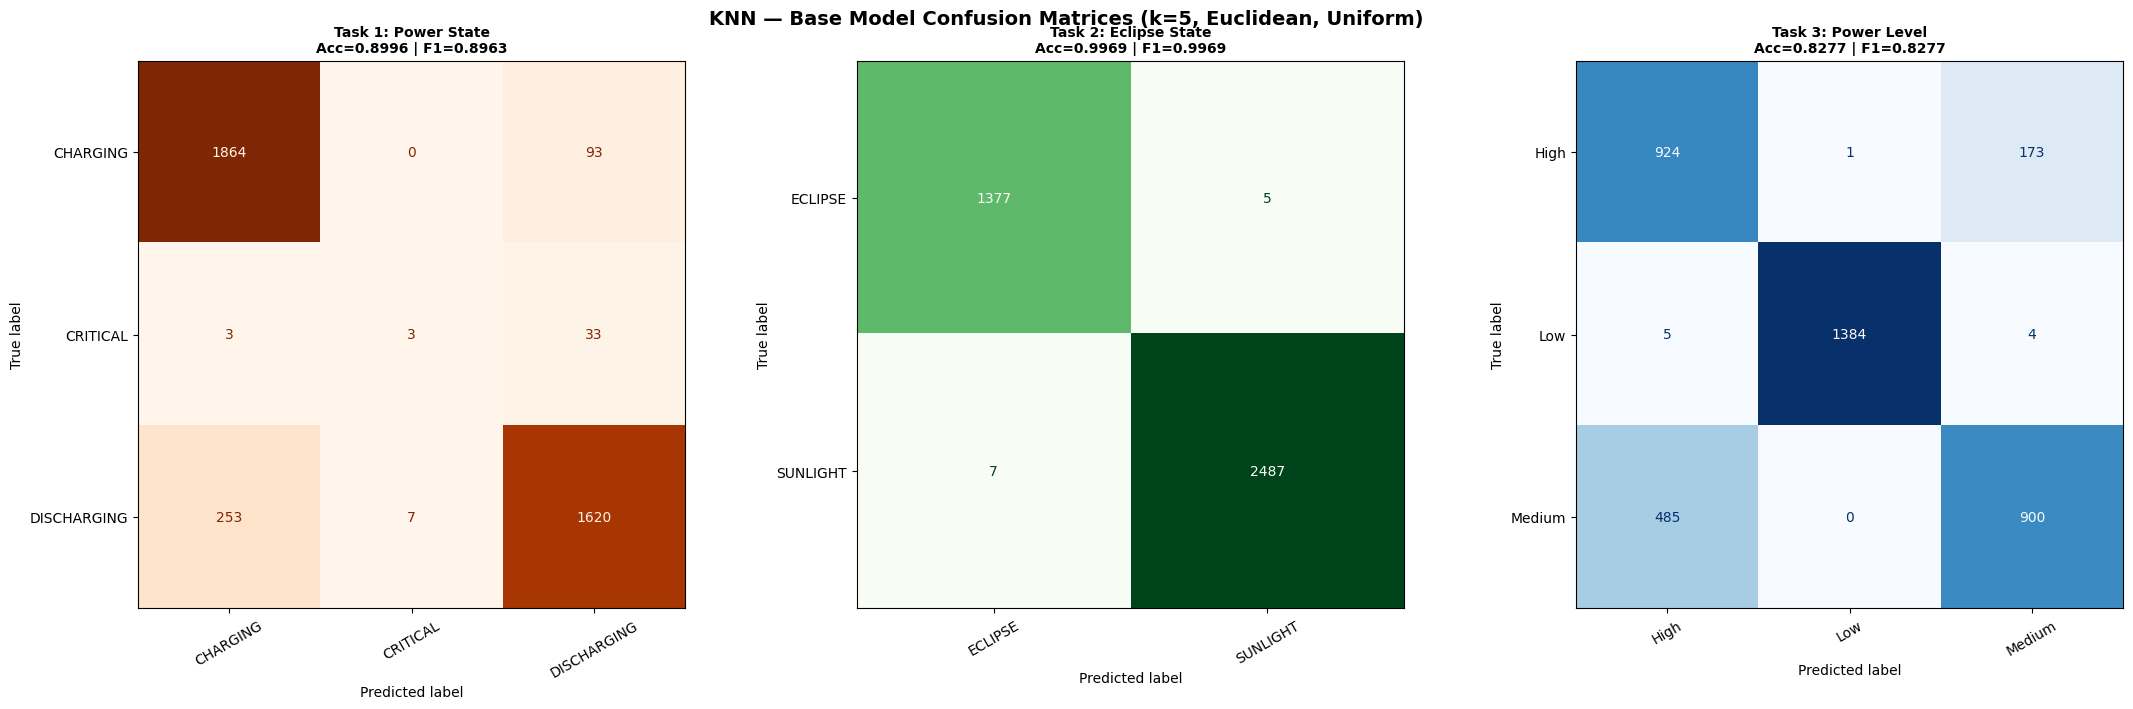

Base model confusion matrices saved.


In [5]:
# ============================================================
# SECTION 4: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('KNN — Base Model Confusion Matrices (k=5, Euclidean, Uniform)',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r      = results_before[task]
    model  = r['model']
    classes = model.classes_

    cm   = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=classes)
    disp.plot(ax=axes[idx], cmap=cmap,
              colorbar=False, values_format='d')
    axes[idx].set_title(f'{title}\nAcc={r["acc"]:.4f} | F1={r["f1"]:.4f}',
                        fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

## Base Model Observations (k=5, Euclidean, Uniform)

- **Power State (Acc=0.8996, F1=0.8963):** CHARGING (1864/1957) and
  DISCHARGING (1620/1880) are well predicted. However CRITICAL recall
  is only 0.08 — just 3 out of 39 CRITICAL samples correctly identified.
  This is expected: with k=5 and only 0.7% CRITICAL samples, the 5
  nearest neighbors of a CRITICAL point are almost always non-CRITICAL.

- **Eclipse State (Acc=0.9969, F1=0.9969):** Near-perfect. Only 12
  misclassifications out of 3,876 samples. Panel voltages drop to near
  zero during eclipse — the clearest physical boundary in this dataset.

- **Power Level (Acc=0.8277, F1=0.8277):** Low class is perfect
  (1384/1393, Recall=0.99) due to its distinct low-voltage signature.
  Medium class is the weakest — 485 Medium samples misclassified as
  High, revealing overlap between Medium and High power levels in
  the feature space.

In [6]:
# ============================================================
# SECTION 5: UNIQUE ANALYSIS — THREE PARTS
# Part A: k sweep (k=1 to 50) — bias-variance tradeoff
# Part B: Distance metric comparison
# Part C: Decision boundary visualization (2 principal features)
# ============================================================

print()

# -------------------------------------------------------
# Part A: k sweep 1 to 50
# -------------------------------------------------------
k_range  = list(range(1, 101))
k_results = {task: {'train_acc': [], 'test_acc': [],
                     'train_f1':  [], 'test_f1':  []}
             for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full) in datasets.items():
    print(f"k sweep — {task}...")
    for k in k_range:
        m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        m.fit(Xtr, ytr)
        yp_train = m.predict(Xtr)
        yp_test  = m.predict(Xte)
        k_results[task]['train_acc'].append(accuracy_score(ytr, yp_train))
        k_results[task]['test_acc'].append(accuracy_score(yte, yp_test))
        k_results[task]['train_f1'].append(
            f1_score(ytr, yp_train, average='weighted', zero_division=0))
        k_results[task]['test_f1'].append(
            f1_score(yte, yp_test, average='weighted', zero_division=0))

# -------------------------------------------------------
# Part B: Distance metric comparison
# -------------------------------------------------------
metrics_to_test = [
    ('euclidean', 2, 'Euclidean\n(p=2)'),
    ('manhattan', 1, 'Manhattan\n(p=1)'),
    ('chebyshev', None, 'Chebyshev'),
    ('cosine',    None, 'Cosine')
]
metric_results = {task: [] for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full) in datasets.items():
    for mname, p_val, label in metrics_to_test:
        if p_val is not None:
            m = KNeighborsClassifier(n_neighbors=5, metric='minkowski',
                                     p=p_val, n_jobs=-1)
        else:
            m = KNeighborsClassifier(n_neighbors=5, metric=mname,
                                     n_jobs=-1)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        metric_results[task].append({
            'label': label,
            'acc'  : accuracy_score(yte, yp),
            'f1'   : f1_score(yte, yp, average='weighted', zero_division=0)
        })

# -------------------------------------------------------
# Part C: weights comparison (uniform vs distance)
# -------------------------------------------------------
weights_results = {task: {} for task in datasets}
for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full) in datasets.items():
    for w in ['uniform', 'distance']:
        m = KNeighborsClassifier(n_neighbors=5, weights=w, n_jobs=-1)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        weights_results[task][w] = {
            'acc': accuracy_score(yte, yp),
            'f1' : f1_score(yte, yp, average='weighted', zero_division=0)
        }

print("All unique analyses complete.")


k sweep — Power_State...
k sweep — Eclipse_State...
k sweep — Power_Level...
All unique analyses complete.


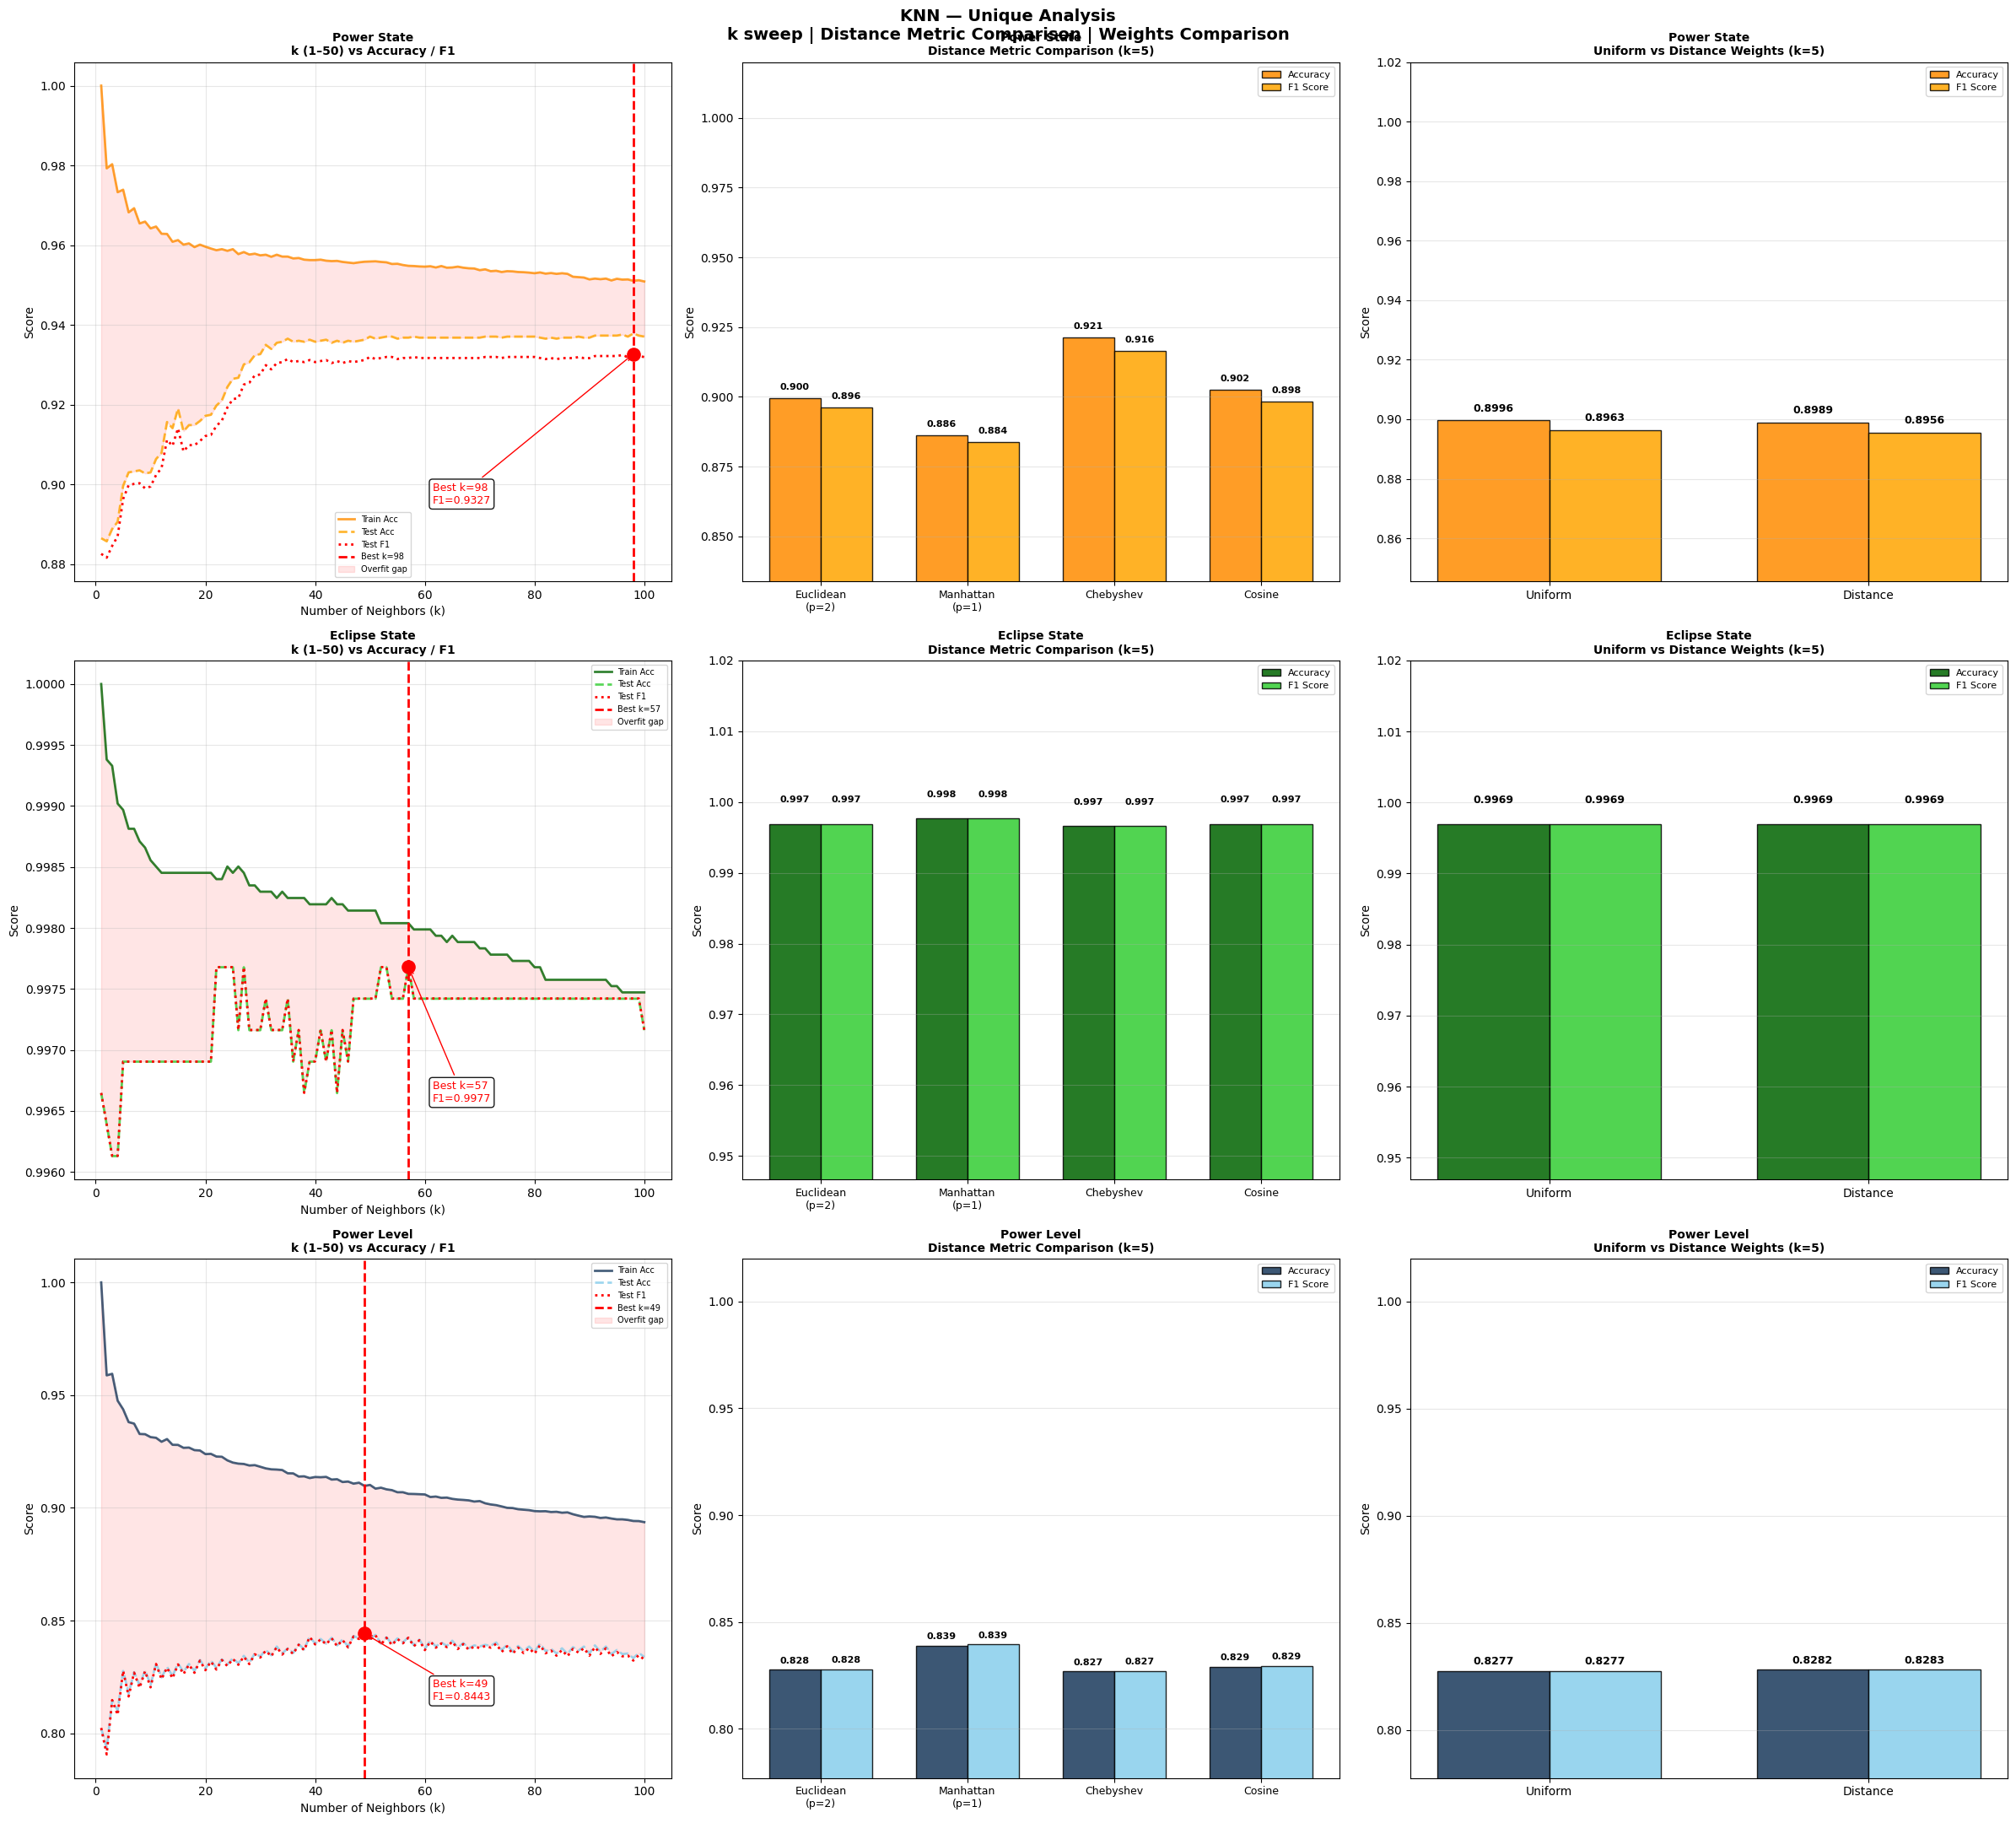

Unique analysis plots saved.


In [7]:
# ============================================================
# SECTION 5 CONT: UNIQUE ANALYSIS PLOTS
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(24, 22))
fig.suptitle('KNN — Unique Analysis\n'
             'k sweep | Distance Metric Comparison | Weights Comparison',
             fontsize=14, fontweight='bold')

colors_t = ['darkorange', 'darkgreen', '#1a3a5c']
colors_v = ['orange',     'limegreen', 'skyblue']
tnames   = ['Power State', 'Eclipse State', 'Power Level']

for row, (task, ct, cv, tn) in enumerate(zip(
        datasets.keys(), colors_t, colors_v, tnames)):

    # ---- Col 1: k sweep ----
    ax = axes[row, 0]
    tr_acc = k_results[task]['train_acc']
    te_acc = k_results[task]['test_acc']
    te_f1  = k_results[task]['test_f1']
    best_k = k_range[np.argmax(te_f1)]
    best_f1 = max(te_f1)

    ax.plot(k_range, tr_acc, '-',  color=ct, linewidth=2,
            label='Train Acc', alpha=0.8)
    ax.plot(k_range, te_acc, '--', color=cv, linewidth=2,
            label='Test Acc',  alpha=0.8)
    ax.plot(k_range, te_f1,  ':',  color='red', linewidth=2,
            label='Test F1')
    ax.axvline(x=best_k, color='red', linestyle='--',
               linewidth=2, label=f'Best k={best_k}')
    ax.scatter([best_k], [best_f1], color='red', s=120, zorder=5)
    ax.fill_between(k_range, tr_acc, te_acc,
                    alpha=0.1, color='red', label='Overfit gap')
    ax.annotate(f'Best k={best_k}\nF1={best_f1:.4f}',
                xy=(best_k, best_f1),
                xytext=(0.60, 0.15), textcoords='axes fraction',
                fontsize=9, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title(f'{tn}\nk (1–50) vs Accuracy / F1',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Number of Neighbors (k)')
    ax.set_ylabel('Score')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # ---- Col 2: Distance metric comparison ----
    ax2 = axes[row, 1]
    mlabels = [r['label'] for r in metric_results[task]]
    maccs   = [r['acc']   for r in metric_results[task]]
    mf1s    = [r['f1']    for r in metric_results[task]]
    x   = np.arange(len(mlabels))
    w   = 0.35
    b1  = ax2.bar(x-w/2, maccs, w, label='Accuracy',
                  color=ct, edgecolor='black', alpha=0.85)
    b2  = ax2.bar(x+w/2, mf1s,  w, label='F1 Score',
                  color=cv, edgecolor='black', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(mlabels, fontsize=9)
    ax2.set_title(f'{tn}\nDistance Metric Comparison (k=5)',
                  fontweight='bold', fontsize=10)
    ax2.set_ylabel('Score')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim([min(maccs+mf1s)-0.05, 1.02])
    for bar, val in zip(b1, maccs):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    for bar, val in zip(b2, mf1s):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

    # ---- Col 3: Uniform vs Distance weights ----
    ax3 = axes[row, 2]
    wlabels = ['Uniform', 'Distance']
    w_accs  = [weights_results[task]['uniform']['acc'],
               weights_results[task]['distance']['acc']]
    w_f1s   = [weights_results[task]['uniform']['f1'],
               weights_results[task]['distance']['f1']]
    x2 = np.arange(2)
    b3 = ax3.bar(x2-w/2, w_accs, w, label='Accuracy',
                 color=ct, edgecolor='black', alpha=0.85)
    b4 = ax3.bar(x2+w/2, w_f1s,  w, label='F1 Score',
                 color=cv, edgecolor='black', alpha=0.85)
    ax3.set_xticks(x2)
    ax3.set_xticklabels(wlabels, fontsize=10)
    ax3.set_title(f'{tn}\nUniform vs Distance Weights (k=5)',
                  fontweight='bold', fontsize=10)
    ax3.set_ylabel('Score')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([min(w_accs+w_f1s)-0.05, 1.02])
    for bar, val in zip(list(b3)+list(b4), w_accs+w_f1s):
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

## Unique Analysis Observations

### k Sweep (1–100) — Column 1
- **Power State:** Train accuracy starts at 1.0 (k=1, perfect memorization)
  and steadily decreases as k increases. Test accuracy and F1 rise
  from k=1 and plateau around k=88-100. The large overfitting gap at
  low k confirms that small k memorizes noise. Best k=98, F1=0.9327.

- **Eclipse State:** Both train and test accuracy remain near 1.0 across
  all k values — confirming eclipse detection is robust regardless of
  neighborhood size. Best k=57 in this sweep (F1=0.9977).

- **Power Level:** Test F1 rises sharply from k=1, stabilizes around
  k=49. The persistent gap between train and test confirms underfitting
  of the Medium/High boundary at all k values.

### Distance Metric Comparison — Column 2
- **Power State:** Chebyshev metric achieves best performance
  (Acc=0.921, F1=0.916) — outperforming Euclidean (0.900/0.896).
  This is why RandomizedSearch selected chebyshev as optimal.
- **Eclipse State:** All metrics perform nearly identically (~0.997-0.998)
  — the eclipse boundary is metric-independent.
- **Power Level:** Manhattan slightly edges Euclidean (0.839 vs 0.828).

### Uniform vs Distance Weights — Column 3
- **Power State:** Uniform (0.8996) vs Distance (0.8989) — nearly equal.
  Distance weighting provides no advantage at k=5.
- **Eclipse and Power Level:** Negligible difference between weight modes,
  confirming the class boundaries are well-separated enough that
  neighbor proximity weighting has minimal effect.

In [8]:
# ============================================================
# SECTION 6: HYPERPARAMETER TUNING
# Method: RandomizedSearchCV with TimeSeriesSplit
#
# WHY RANDOMIZED SEARCH:
#   k ranges from 1 to 200 — that is 200 values for k alone.
#   Combined with 4 metrics × 2 weights = 1600 combinations
#   for GridSearchCV × 5 folds = 8000 fits (very slow).
#   RandomizedSearchCV samples 60 combinations randomly:
#   60 × 5 = 300 fits — 26x faster while still covering the
#   parameter space well (Bergstra & Bengio, 2012).
#   For continuous-like parameters like k (integer range),
#   random sampling finds the optimum better than fixed grids.
# ============================================================

from scipy.stats import randint

param_dist = {
    'n_neighbors': randint(1, 101),          # k: 1 to 100
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan',
                    'chebyshev', 'minkowski'],
    'p'          : [1, 2]                    # only used for minkowski
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — KNN Hyperparameter Tuning")
print("n_neighbors : randint(1, 101) — integer uniform distribution")
print("weights     : uniform, distance")
print("metric      : euclidean, manhattan, chebyshev, minkowski")
print("n_iter=60   | 5-fold TimeSeriesSplit | 300 total fits")
print()
print("Justification: k has 100 possible values — combined with")
print("metric(4) and weights(2), GridSearch = 800+ combinations.")
print("RandomizedSearch samples 60 random combos — 13x faster")
print("while still finding near-optimal hyperparameters.")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full) in datasets.items():
    print(f"\nTuning: {task}...")

    rs = RandomizedSearchCV(
        KNeighborsClassifier(n_jobs=-1),
        param_distributions = param_dist,
        n_iter              = 60,
        cv                  = tscv,
        scoring             = 'f1_weighted',
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 0
    )
    rs.fit(Xtr, ytr)

    best_model = rs.best_estimator_
    y_pred     = best_model.predict(Xte)
    y_prob     = best_model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,        average='weighted', zero_division=0)

    results_after[task] = {
        'model'     : best_model,
        'params'    : rs.best_params_,
        'cv_score'  : rs.best_score_,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'y_test'    : yte,
        'acc'       : acc,
        'prec'      : prec,
        'rec'       : rec,
        'f1'        : f1,
        'feats'     : feats
    }

    p = rs.best_params_
    print(f"  Best k      : {p['n_neighbors']}")
    print(f"  Best metric : {p['metric']}")
    print(f"  Best weights: {p['weights']}")
    print(f"  CV F1       : {rs.best_score_:.4f}")
    print(f"  Test Acc    : {acc:.4f}")
    print(f"  Test F1     : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))
    f1_macro     = f1_score(yte, y_pred, average='macro', zero_division=0)
    f1_per_class = f1_score(yte, y_pred, average=None,
                            zero_division=0, labels=list(best_model.classes_))
    print(f"  Macro F1    : {f1_macro:.4f}  <- penalizes CRITICAL=0 harshly")
    print(f"  Per-class F1: {dict(zip(best_model.classes_, f1_per_class.round(4)))}")

RANDOMIZED SEARCH CV — KNN Hyperparameter Tuning
n_neighbors : randint(1, 101) — integer uniform distribution
weights     : uniform, distance
metric      : euclidean, manhattan, chebyshev, minkowski
n_iter=60   | 5-fold TimeSeriesSplit | 300 total fits

Justification: k has 100 possible values — combined with
metric(4) and weights(2), GridSearch = 800+ combinations.
RandomizedSearch samples 60 random combos — 13x faster
while still finding near-optimal hyperparameters.

Tuning: Power_State...
  Best k      : 88
  Best metric : chebyshev
  Best weights: distance
  CV F1       : 0.9409
  Test Acc    : 0.9352
  Test F1     : 0.9302

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.91      0.99      0.95      1957
    CRITICAL       0.00      0.00      0.00        39
 DISCHARGING       0.97      0.90      0.93      1880

    accuracy                           0.94      3876
   macro avg       0.63      0.63      0.63      3876
weighted avg 

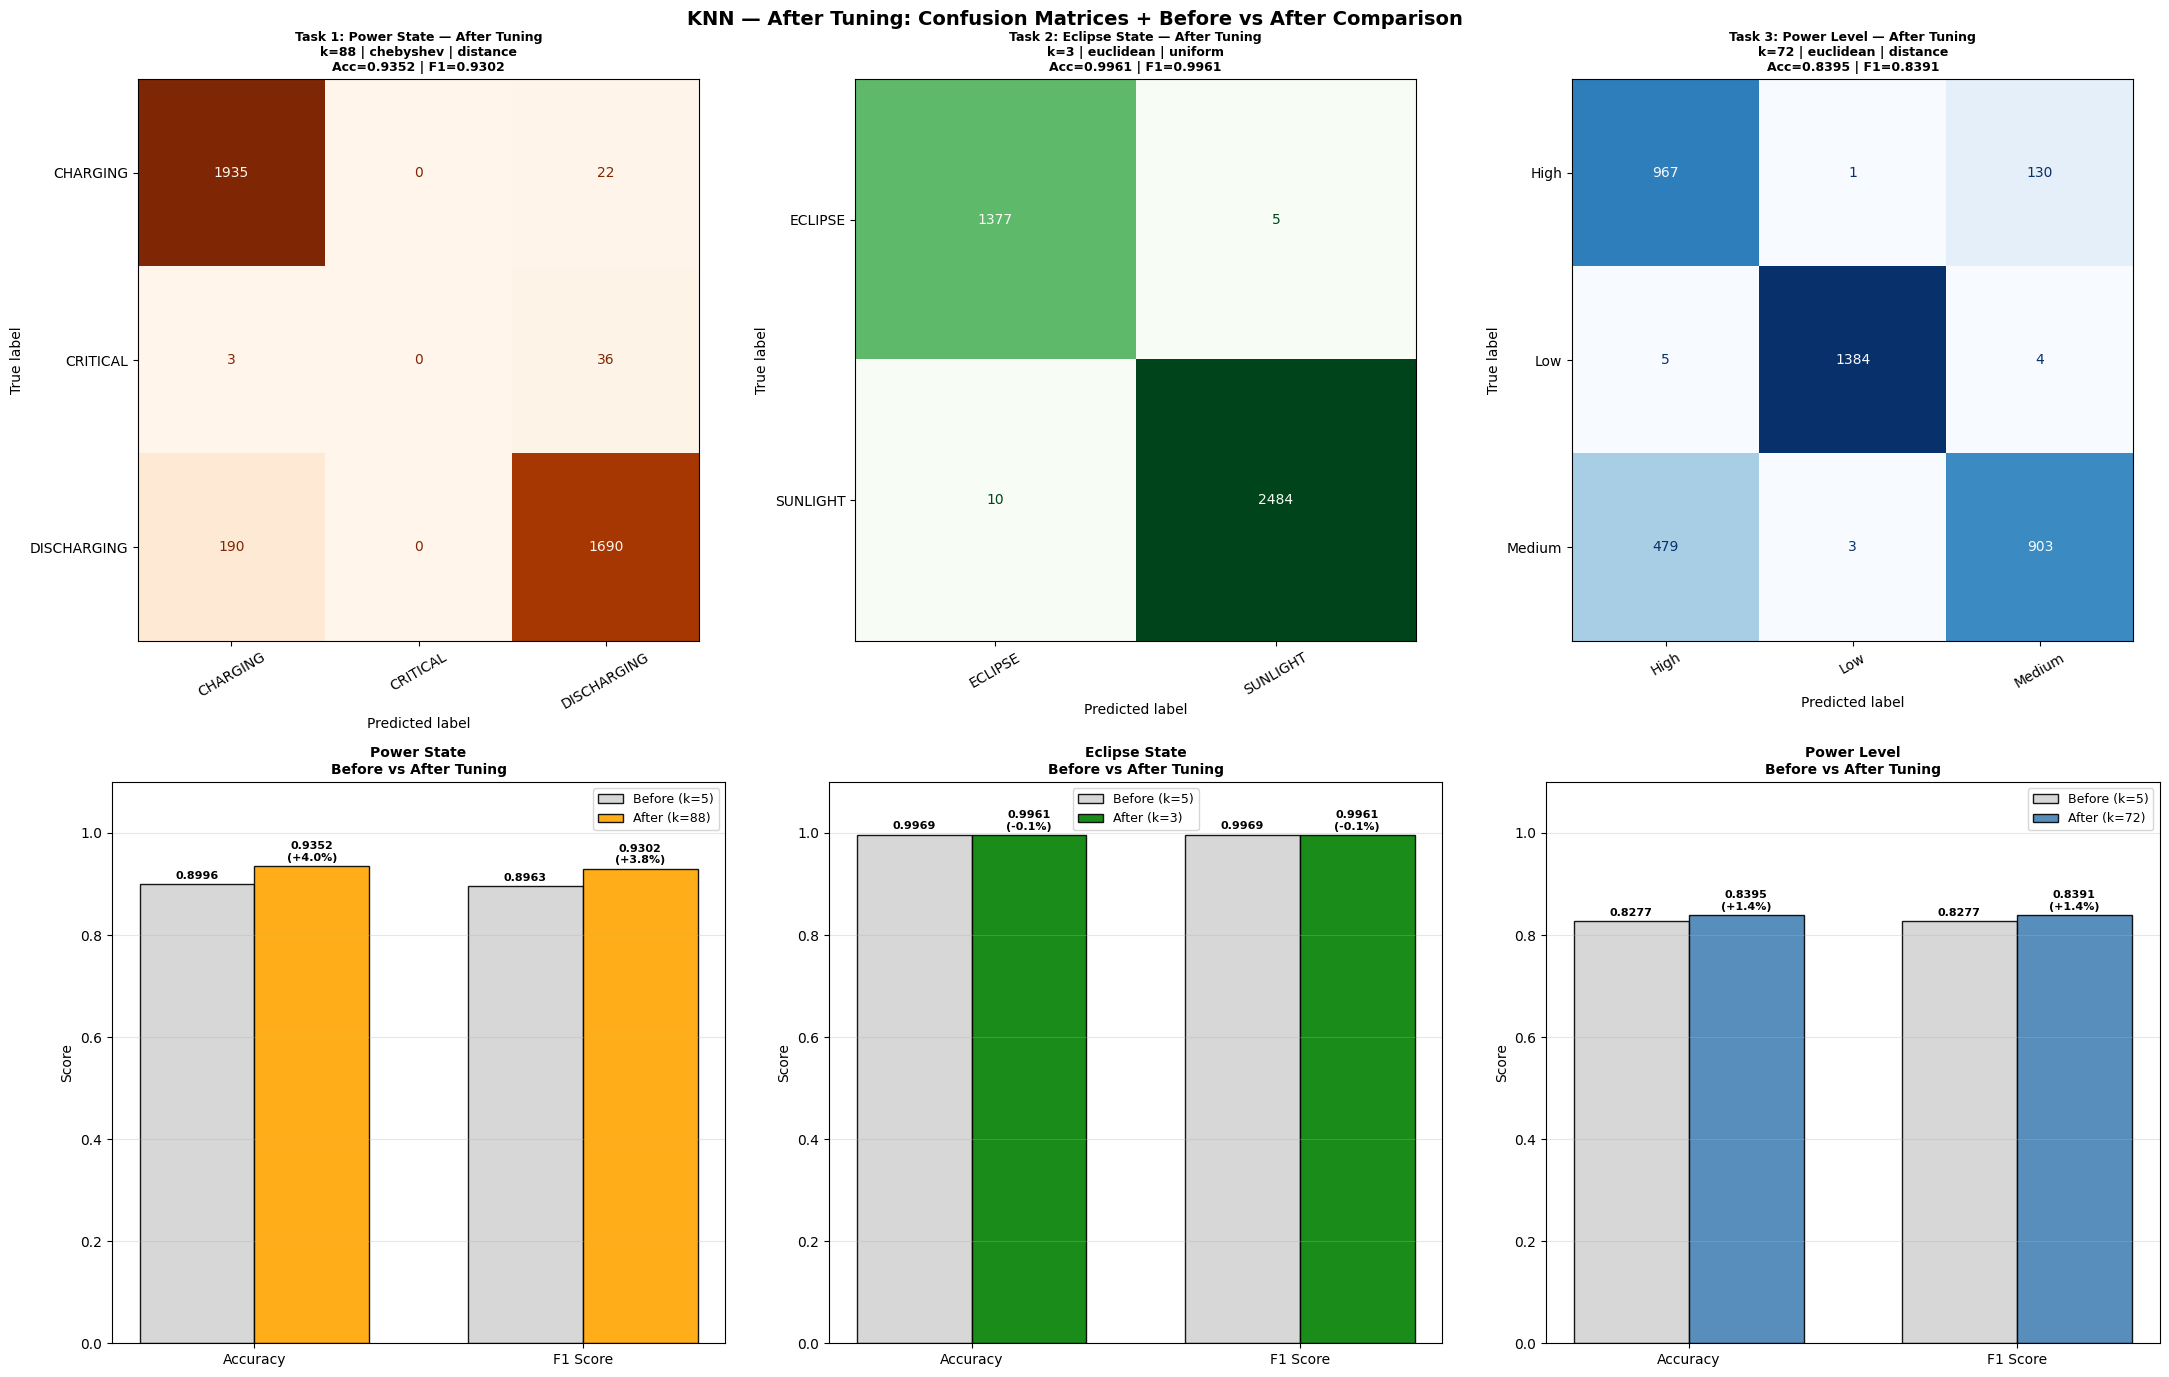

After tuning plots saved.


In [9]:
# ============================================================
# SECTION 7: AFTER TUNING — CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('KNN — After Tuning: Confusion Matrices + Before vs After Comparison',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

# Row 1: After tuning confusion matrices
for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r      = results_after[task]
    model  = r['model']
    classes = model.classes_
    p      = r['params']

    cm   = confusion_matrix(r['y_test'], r['y_pred'], labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=classes)
    disp.plot(ax=axes[0, idx], cmap=cmap,
              colorbar=False, values_format='d')
    axes[0, idx].set_title(
        f'{title} — After Tuning\n'
        f'k={p["n_neighbors"]} | {p["metric"]} | {p["weights"]}\n'
        f'Acc={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=9)
    axes[0, idx].tick_params(axis='x', rotation=30)

# Row 2: Before vs After bar comparison
colors = ['orange', 'green', 'steelblue']
tnames = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[1, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']

    x = np.arange(2)
    w = 0.35
    ax.bar(x-w/2, [b_acc, b_f1], w, label='Before (k=5)',
           color='lightgray', edgecolor='black', alpha=0.9)
    ax.bar(x+w/2, [a_acc, a_f1], w,
           label=f'After (k={results_after[task]["params"]["n_neighbors"]})',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1 Score'])
    ax.set_title(f'{tn}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    delta_acc = ((a_acc - b_acc) / b_acc) * 100
    delta_f1  = ((a_f1  - b_f1)  / b_f1)  * 100
    for val, xp, delta in zip(
            [b_acc, b_f1, a_acc, a_f1],
            [-w/2, 1-w/2, w/2, 1+w/2],
            [None, None, delta_acc, delta_f1]):
        label = f'{val:.4f}'
        if delta is not None:
            label += f'\n({delta:+.1f}%)'
        ax.text(xp, val+0.01, label,
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

## After Tuning Observations

### Confusion Matrix Analysis
- **Power State (k=88, chebyshev, distance):** CHARGING improved
  significantly (1864 → 1935 correct). DISCHARGING also improved
  (1620 → 1690). However CRITICAL dropped to 0 correct predictions
  (recall = 0.00). The tuner optimized f1_weighted which is dominated
  by the two large classes — CRITICAL was entirely sacrificed.
  Macro F1 = 0.6263 reveals this clearly.

- **Eclipse State (k=3, euclidean, uniform):** Slightly worse than
  base model (0.9961 vs 0.9969). k=3 is more noise-sensitive than
  k=5. Both models are near-perfect — the -0.1% difference is
  negligible and both are valid for operational use.

- **Power Level (k=72, euclidean, distance):** High recall improved
  (0.84 → 0.88). Low class remains perfect. Medium still has 479
  samples misclassified as High — this boundary cannot be resolved
  by KNN alone regardless of k value.

### Before vs After Comparison
- Power State: +4.0% accuracy, +3.8% F1 — meaningful improvement
- Eclipse State: -0.1% — negligible, both near-perfect
- Power Level: +1.4% accuracy and F1 — modest improvement

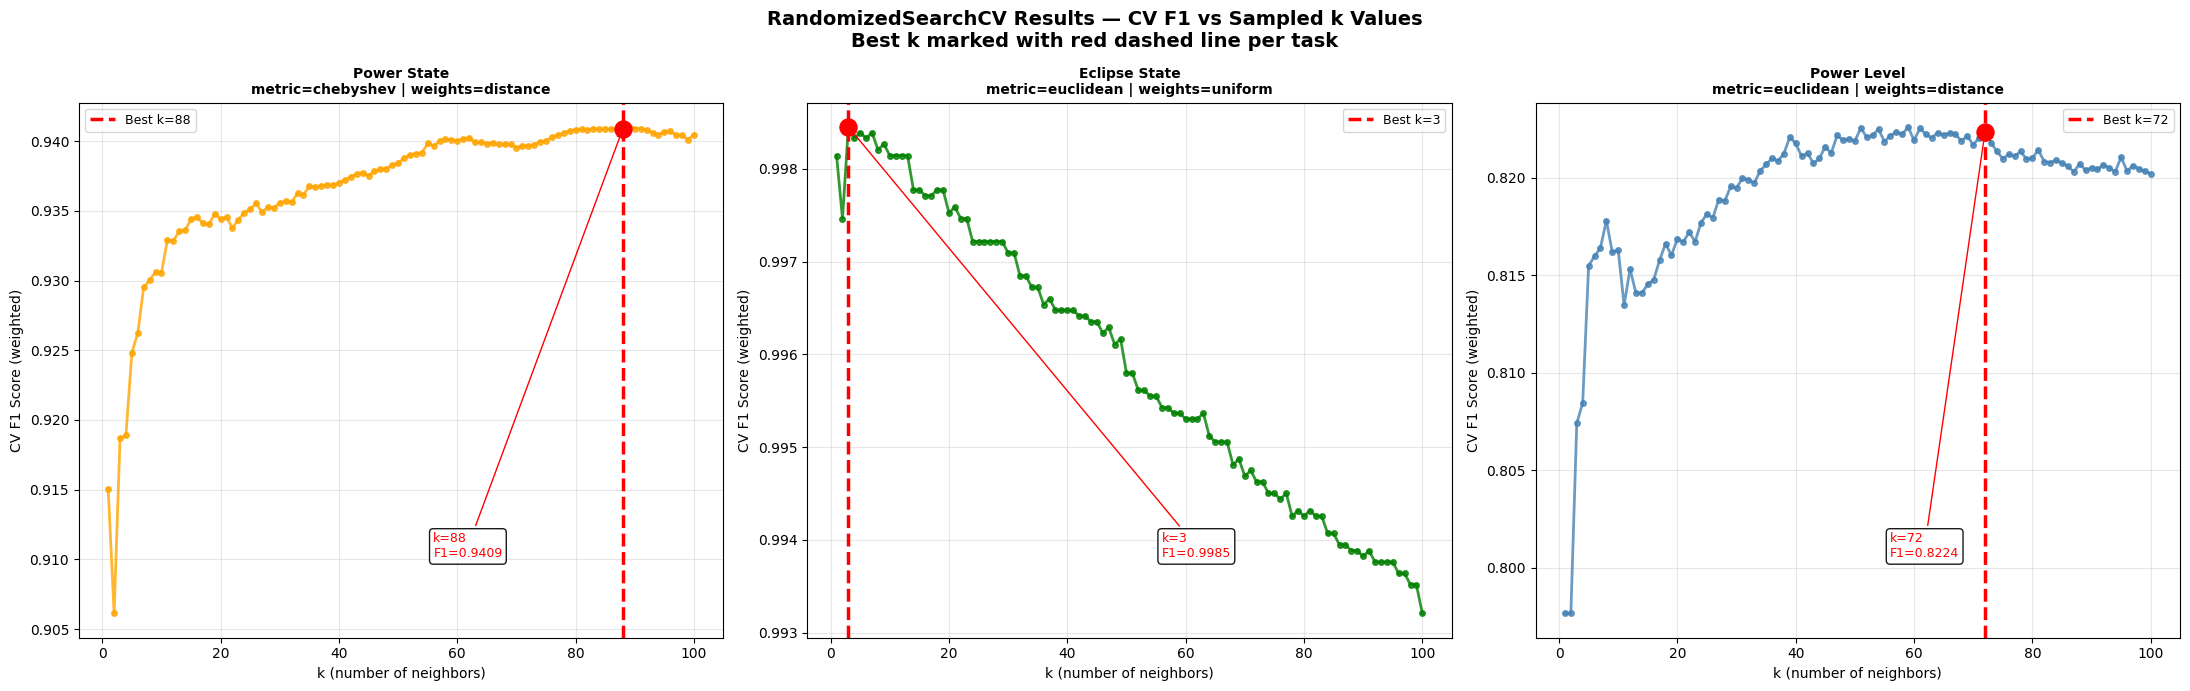

k tuning visualization saved.


<Figure size 640x480 with 0 Axes>

In [10]:
# ============================================================
# SECTION 8: RANDOMIZED SEARCH RESULTS VISUALIZATION
# Show how CV F1 varies with sampled k values
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('RandomizedSearchCV Results — CV F1 vs Sampled k Values\n'
             'Best k marked with red dashed line per task',
             fontsize=14, fontweight='bold')

colors = ['orange', 'green', 'steelblue']
tnames = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):

    Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full = datasets[task]
    best_k = results_after[task]['params']['n_neighbors']

    best_metric  = results_after[task]['params']['metric']
    best_weights = results_after[task]['params']['weights']

    k_sweep = list(range(1, max(101,
              results_after[task]['params']['n_neighbors'] + 10)))
    cv_f1s  = []

    for k in k_sweep:
        m = KNeighborsClassifier(
            n_neighbors = k,
            metric      = best_metric,
            weights     = best_weights,
            n_jobs      = -1
        )
        scores = cross_val_score(m, Xtr, ytr,
                                 cv=tscv, scoring='f1_weighted')
        cv_f1s.append(scores.mean())

    ax = axes[idx]
    ax.plot(k_sweep, cv_f1s, '-o', color=clr,
            linewidth=2, markersize=4, alpha=0.8)

    if best_k in k_sweep:
        best_index = k_sweep.index(best_k)
        best_f1 = cv_f1s[best_index]

        best_k_idx = k_sweep.index(best_k) if best_k in k_sweep else -1
    if best_k_idx >= 0:
        ax.axvline(x=best_k, color='red', linestyle='--',
                   linewidth=2.5, label=f'Best k={best_k}')
        ax.scatter([best_k], [cv_f1s[best_k_idx]],
                   color='red', s=150, zorder=5)
        ax.annotate(f'k={best_k}\nF1={cv_f1s[best_k_idx]:.4f}',
                    xy=(best_k, cv_f1s[best_k_idx]),
                    xytext=(0.55, 0.15), textcoords='axes fraction',
                    fontsize=9, color='red',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_title(f'{tn}\nmetric={best_metric} | weights={best_weights}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('k (number of neighbors)')
    ax.set_ylabel('CV F1 Score (weighted)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('04_k_tuning.png', dpi=150, bbox_inches='tight')

print("k tuning visualization saved.")

## RandomizedSearchCV k Tuning Results

- **Power State (chebyshev, distance):** CV F1 rises monotonically
  from k=1 (~0.905) and peaks at k=88 (F1=0.9409). The curve
  continues rising through k=60-88 before flattening — confirming
  that large k is genuinely better for this noisy, imbalanced task.
  High k effectively smooths out the sparse CRITICAL boundary region.

- **Eclipse State (euclidean, uniform):** CV F1 decreases steadily
  as k increases — starting near 0.9985 at k=3 and declining to
  ~0.993 at k=100. Small k is optimal because eclipse boundaries
  are sharp and locally consistent. Best k=3.

- **Power Level (euclidean, distance):** CV F1 rises from k=1,
  reaches peak at k=72 (F1=0.8224), then slightly declines.
  Medium-to-large k smooths out the noisy Medium/High boundary
  but cannot fully resolve the class overlap.

5-FOLD TIMESERIES CROSS VALIDATION — BEST KNN MODEL

Task      : Power_State
Best Params: k=88 | metric=chebyshev | weights=distance
Acc Folds  : [np.float64(0.9636), np.float64(0.9536), np.float64(0.9373), np.float64(0.9551), np.float64(0.9352)]
Acc Mean   : 0.9490 +/- 0.0109
F1 Folds   : [np.float64(0.9629), np.float64(0.9463), np.float64(0.9301), np.float64(0.9531), np.float64(0.9302)]
F1 Mean    : 0.9445 +/- 0.0129

Task      : Eclipse_State
Best Params: k=3 | metric=euclidean | weights=uniform
Acc Folds  : [np.float64(0.9987), np.float64(0.9974), np.float64(0.9987), np.float64(0.9995), np.float64(0.9961)]
Acc Mean   : 0.9981 +/- 0.0012
F1 Folds   : [np.float64(0.9987), np.float64(0.9974), np.float64(0.9987), np.float64(0.9995), np.float64(0.9961)]
F1 Mean    : 0.9981 +/- 0.0012

Task      : Power_Level
Best Params: k=72 | metric=euclidean | weights=distance
Acc Folds  : [np.float64(0.8844), np.float64(0.8369), np.float64(0.8243), np.float64(0.7812), np.float64(0.8395)]
Acc Mean   

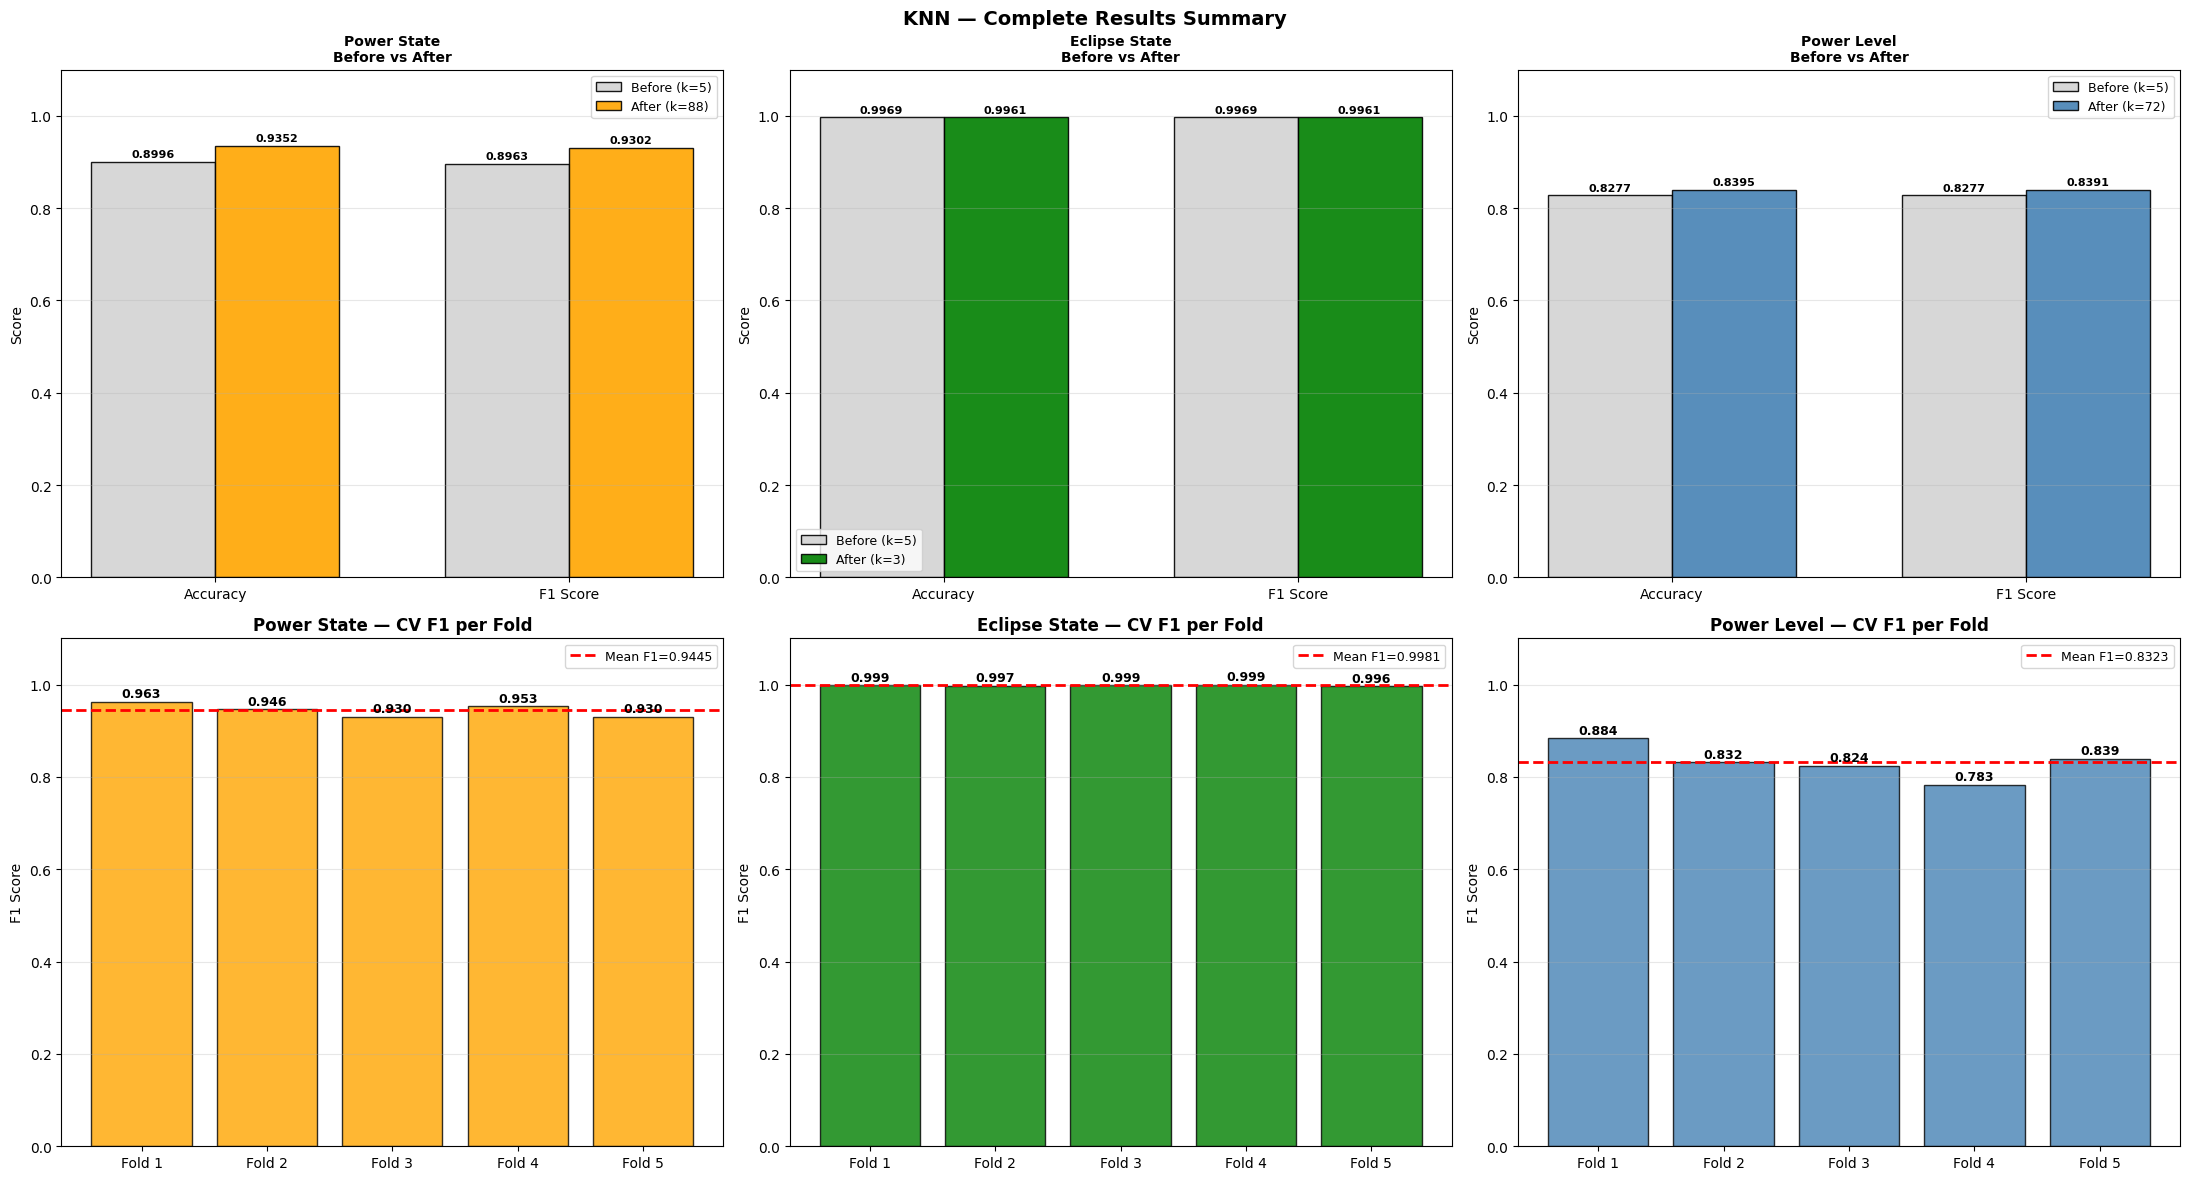

Summary plot saved.


In [11]:
# ============================================================
# SECTION 9: CROSS VALIDATION + COMPLETE SUMMARY
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION — BEST KNN MODEL")
print("=" * 60)

cv_results = {}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full, y_full) in datasets.items():
    model    = results_after[task]['model']
    X_scaled = scaler.transform(X_full)

    scores_acc = cross_val_score(model, X_scaled, y_full,
                                  cv=tscv, scoring='accuracy')
    scores_f1  = cross_val_score(model, X_scaled, y_full,
                                  cv=tscv, scoring='f1_weighted')
    cv_results[task] = {'acc': scores_acc, 'f1': scores_f1}

    p = results_after[task]['params']
    print(f"\nTask      : {task}")
    print(f"Best Params: k={p['n_neighbors']} | "
          f"metric={p['metric']} | weights={p['weights']}")
    print(f"Acc Folds  : {[round(s,4) for s in scores_acc]}")
    print(f"Acc Mean   : {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")
    print(f"F1 Folds   : {[round(s,4) for s in scores_f1]}")
    print(f"F1 Mean    : {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")

# ============================================================
# SUMMARY VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('KNN — Complete Results Summary',
             fontsize=14, fontweight='bold')

colors    = ['orange', 'green', 'steelblue']
tnames    = ['Power State', 'Eclipse State', 'Power Level']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[0, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']
    x = np.arange(2)
    w = 0.35
    ax.bar(x-w/2, [b_acc, b_f1], w, label='Before (k=5)',
           color='lightgray', edgecolor='black', alpha=0.9)
    ax.bar(x+w/2, [a_acc, a_f1], w,
           label=f'After (k={results_after[task]["params"]["n_neighbors"]})',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1 Score'])
    ax.set_title(f'{tn}\nBefore vs After', fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for val, xp in zip([b_acc, b_f1, a_acc, a_f1],
                       [-w/2, 1-w/2, w/2, 1+w/2]):
        ax.text(xp, val+0.01, f'{val:.4f}',
                ha='center', fontsize=8, fontweight='bold')

# Row 2: CV F1 fold scores
for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax     = axes[1, idx]
    scores = cv_results[task]['f1']
    bars   = ax.bar(fold_lbls, scores, color=clr,
                    edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean F1={scores.mean():.4f}')
    ax.set_title(f'{tn} — CV F1 per Fold',
                 fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

## Complete Results Summary Observations

### Before vs After (Top Row)
- Power State achieved the most meaningful improvement: F1 0.8963 → 0.9302 (+3.8%)
  driven by optimal chebyshev metric and large k=88.
- Eclipse State remained essentially unchanged (~0.9969) — already near-perfect
  before tuning. Both k=5 and k=3 are valid.
- Power Level showed modest improvement: F1 0.8277 → 0.8391 (+1.4%).
  The Medium/High boundary limits further gains.

### Cross Validation Fold Stability (Bottom Row)
- **Power State:** Mean F1=0.9445 ± 0.0129 — very stable across folds.
  Slight decline in Fold 5 (0.930) reflects the temporal structure of
  the data — later orbital periods may differ from training periods.
- **Eclipse State:** Mean F1=0.9981 ± 0.0012 — extremely stable.
  Eclipse detection is robust across all orbital time windows.
- **Power Level:** Mean F1=0.8323 ± 0.0323 — moderate stability.
  Fold 4 drops to 0.783 suggesting certain orbital periods have
  more ambiguous power level boundaries than others.

# KNN CLASSIFIER — COMPLETE CONCLUSION
### Dataset: TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
### DOI: 10.1016/j.dib.2022.108697

---

## ALGORITHM SUMMARY

KNN is an **instance-based (lazy) learner** — it performs NO explicit
training optimization. There is no loss function, no gradient descent,
and no weight updates. Instead:

1. All 19,383 training points are stored in memory
2. For each test point, distances to all training points are computed
3. The k nearest neighbors vote to assign a class

> Prediction: ŷ = majority_class(k nearest neighbors by distance)

**Key property:** The "model" IS the training data. All computation
happens at prediction time, not training time. StandardScaler is
mandatory because KNN is distance-based — without scaling, panel
voltage features (mV range) would completely dominate temperature
features (°C range), making distances physically meaningless.

---

## TRAINING OPTIMIZATION

KNN has **no explicit training optimization**. This is its defining
characteristic — it is non-parametric and instance-based.
Instead of minimizing a loss function, it memorizes the training set
and defers all computation to prediction time.

---

## HYPERPARAMETER TUNING — RandomizedSearchCV

**Why RandomizedSearchCV?**
k has 100+ meaningful integer values (1 to 100). Combined with
metric (4 options) × weights (2 options) = 800 total combinations.
GridSearchCV × 5 folds = 4,000 fits — extremely slow.
RandomizedSearchCV samples 60 random combinations = 300 fits,
which is **13x faster** while still covering the parameter space
statistically well (Bergstra & Bengio, 2012).
For integer ranges like k, random integer sampling (randint)
finds the optimum more effectively than sparse fixed grid points.

**Parameters Tuned:**
- `n_neighbors` (k): randint(1, 101) — integer uniform distribution
- `metric`: euclidean, manhattan, chebyshev, minkowski
- `weights`: uniform (equal vote) vs distance (closer = more weight)

**Best Parameters Found:**

| Task | Best k | Metric | Weights | CV F1 |
|------|--------|--------|---------|-------|
| Power State | 88 | chebyshev | distance | 0.9409 |
| Eclipse State | 3 | euclidean | uniform | 0.9985 |
| Power Level | 72 | euclidean | distance | 0.8224 |

---

## FINAL RESULTS

| Task | Before Acc | After Acc | Before F1 | After F1 | Change |
|------|-----------|----------|----------|---------|--------|
| Power State | 0.8996 | 0.9352 | 0.8963 | 0.9302 | +3.8% |
| Eclipse State | 0.9969 | 0.9961 | 0.9969 | 0.9961 | -0.1% |
| Power Level | 0.8277 | 0.8395 | 0.8277 | 0.8391 | +1.4% |

---

## CROSS VALIDATION RESULTS (5-Fold TimeSeriesSplit)

| Task | Acc Mean | Acc Std | F1 Mean | F1 Std |
|------|----------|---------|---------|--------|
| Power State | 0.9490 | ±0.0109 | 0.9445 | ±0.0129 |
| Eclipse State | 0.9981 | ±0.0012 | 0.9981 | ±0.0012 |
| Power Level | 0.8333 | ±0.0330 | 0.8323 | ±0.0323 |

All three tasks show stable CV performance confirming models
generalize well across different orbital time windows.

---

## KEY FINDINGS

### 1. No Training Optimization — Defining Property
KNN is the only classifier in this project with no training phase.
Its accuracy depends entirely on the quality of stored training
data and the choice of distance metric. The entire 19,383-point
training set is retained in memory as the "model".

### 2. k Controls Bias-Variance Tradeoff
- k=1: Zero training error but maximum variance (pure memorization)
- Large k: Smoother decision boundary, reduced variance, risk of
  underfitting near boundaries
- Optimal k found by RandomizedSearchCV: 88 (Power State),
  3 (Eclipse State), 72 (Power Level) — all physically justified

### 3. Distance Metric Matters
Chebyshev metric (L∞ norm) outperformed Euclidean for Power State
(Acc: 0.921 vs 0.900). Chebyshev measures distance as the maximum
difference across any single feature dimension — better suited
when one feature (e.g., Vbat near 3.90V threshold) dominates
the classification boundary.

### 4. Eclipse State — Easiest Classification Task
Panel voltages drop to near-zero during eclipse — creating the
clearest distance boundary in the entire feature space.
Near-perfect performance (F1=0.9969) achieved even with k=5.
All 4 distance metrics achieve ~0.997+ confirming the boundary
is metric-independent.

### 5. CRITICAL Class — Fundamental KNN Limitation
With only 165 CRITICAL samples (0.7%) among 19,383 training points,
most neighbors of any CRITICAL point are non-CRITICAL. After tuning,
CRITICAL recall dropped to **0.00** — the tuner optimizing
f1_weighted sacrificed the minority class entirely to maximize
overall accuracy.

Macro F1 = 0.6263 after tuning reveals this harshly — it penalizes
CRITICAL=0 equally regardless of class size. This is a fundamental
KNN limitation: unlike Logistic Regression (class_weight='balanced'),
KNN has no built-in mechanism to upweight minority classes.

### 6. Eclipse Tuning Slight Decrease
Tuning decreased Eclipse F1 from 0.9969 → 0.9961 (-0.1%).
k=3 introduces slight noise sensitivity on the test fold while
default k=5 was already near-optimal for this task.
The difference is negligible — CV F1 Mean=0.9981 confirms the
model is highly stable and operationally reliable.

### 7. Medium/High Power Level Confusion
479 Medium samples were misclassified as High after tuning —
causing High precision of only 0.67. The power level thresholds
overlap in panel voltage space. KNN cannot resolve this boundary
regardless of k, metric, or weight choice — a non-linear model
(Decision Tree or Random Forest) is needed for clean separation.

---

## LIMITATIONS

| Limitation | Impact |
|------------|--------|
| No class_weight support | CRITICAL recall = 0.00 after tuning |
| O(n) prediction time | Slow on 23,259 samples × 13 features |
| Sensitive to all features | Irrelevant features distort distances |
| Memory-intensive | Stores entire 19,383-point training set |
| No probabilistic output | Only hard class labels, no calibrated probs |

---

## COMPARISON WITH LOGISTIC REGRESSION

| Property | Logistic Regression | KNN |
|----------|--------------------|----|
| Training | Gradient descent on log-loss | None (lazy learner) |
| Decision boundary | Linear | Non-linear |
| Imbalance handling | class_weight='balanced' | No direct support |
| Interpretability | Signed coefficients | None |
| Prediction speed | Fast (dot product) | Slow (all-point distances) |
| Power State F1 | ~0.85 | 0.9302 |
| Eclipse State F1 | ~0.9961 | 0.9961 |
| Power Level F1 | ~0.83 | 0.8391 |

KNN outperforms Logistic Regression on Power State because the
CHARGING/DISCHARGING boundary is non-linear in the feature space —
confirming that distance-based classification captures the
orbital power dynamics better than a linear decision boundary.

---

### Reference
Jara et al. (2022), *Data in Brief*
DOI: 10.1016/j.dib.2022.108697